# Predictive Analytics and Explainable AI for Hospital Readmission Risk

**Course:** CS 719 — Data Science  
**Student:** Raj Panchal (200490453)  
**Instructor:** Dr. Howard J. Hamilton  
**University of Regina** | Winter 2026  

---

**Objective:** Predict whether a diabetic patient will be readmitted within 30 days using the Diabetes 130-US Hospitals dataset (101,766 encounters). Train Logistic Regression, Random Forest, and XGBoost classifiers, tune hyperparameters via GridSearchCV, select the best model, and apply Permutation Feature Importance (PFI) and Partial Dependence Plots (PDP) for explainability.

---

### Table of Contents
1. Setup & Imports
2. Data Loading & Inspection
3. Data Cleaning
4. Feature Engineering & Binary Target
5. Exploratory Data Analysis (EDA)
6. Statistical Tests
7. Preprocessing (Encoding, Splitting, SMOTE, Scaling)
8. Model Training & Hyperparameter Tuning
9. Model Evaluation & Comparison
10. Best Model Selection
11. Explainability — Permutation Feature Importance (PFI)
12. Explainability — Partial Dependence Plots (PDP)
13. Classification Threshold Analysis
14. Sample Predictions — Actual vs Predicted (Live Demo)
15. Patient Risk Assessment — Interactive Prediction
16. Export Model Artifacts for Streamlit Dashboard
17. Conclusion

In [10]:
# === COLAB SETUP ===
!pip install -q imbalanced-learn xgboost

# Upload files
from google.colab import files
import os

# Create directory structure
os.makedirs('src', exist_ok=True)
os.makedirs('Data', exist_ok=True)

# Upload readmission_utils.py → put it in src/
print("Upload readmission_utils.py:")
uploaded = files.upload()
for name, data in uploaded.items():
    with open(f'src/{name}', 'wb') as f:
        f.write(data)

# Create __init__.py
with open('src/__init__.py', 'w') as f:
    pass

# Upload diabetic_data.csv → put it in Data/
print("\nUpload diabetic_data.csv:")
uploaded = files.upload()
for name, data in uploaded.items():
    with open(f'Data/{name}', 'wb') as f:
        f.write(data)

print("\nSetup complete!")


Upload ds_utils.py:



Upload diabetic_data.csv:



Setup complete!


---
## 1. Setup & Imports

In [11]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('.'))
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

from src.readmission_utils import (
    profile,
    detect_outliers_iqr,
    plot_distributions,
    plot_correlation_matrix,
    plot_categorical_counts,
    plot_target_distribution,
    plot_target_vs_features,
    clean_diabetes_data,
    engineer_features,
    create_binary_target,
    encode_and_prepare,
    evaluate_classifier,
    plot_confusion_matrices,
    plot_roc_curves,
    plot_precision_recall_curves,
    compare_models,
    quick_cross_val,
    cross_val_box_plot,
    plot_permutation_importance,
    plot_partial_dependence,
    threshold_analysis,
    normality_test,
    correlation_test,
    chi2_test,
)

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline
print('All imports successful!')

All imports successful!


---
## 2. Data Loading & Inspection

In [12]:
df_raw = pd.read_csv('Data/diabetic_data.csv')
print(f'Dataset shape: {df_raw.shape}')
print(f'Columns ({len(df_raw.columns)}): {df_raw.columns.tolist()}')
df_raw.head()

Dataset shape: (101766, 50)
Columns (50): ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [13]:
print('Data types:')
print(df_raw.dtypes.value_counts())
print(f'\nMemory usage: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Data types:
object    37
int64     13
Name: count, dtype: int64

Memory usage: 202.2 MB


In [14]:
# Full data profile
prof = profile(df_raw)
prof

,dtype,non_null,null_count,null_pct,unique,mean,std,min,25%,50%,75%,max,skew,kurtosis
column,,,,,,,,,,,,,,
encounter_id,int64,101766,0,0.00,101766,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0,0.6991,-0.1021
patient_nbr,int64,101766,0,0.00,71518,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0,0.4713,-0.3474
race,object,101766,0,0.00,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,object,101766,0,0.00,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,object,101766,0,0.00,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,object,101766,0,0.00,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,int64,101766,0,0.00,8,2.024000e+00,1.445400e+00,1.0,1.0,1.0,3.000000e+00,8.0,1.5920,1.9425
discharge_disposition_id,int64,101766,0,0.00,26,3.715600e+00,5.280200e+00,1.0,1.0,1.0,4.000000e+00,28.0,2.5631,6.0033
admission_source_id,int64,101766,0,0.00,17,5.754400e+00,4.064100e+00,1.0,1.0,7.0,7.000000e+00,25.0,1.0299,1.7450


Original readmitted distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64



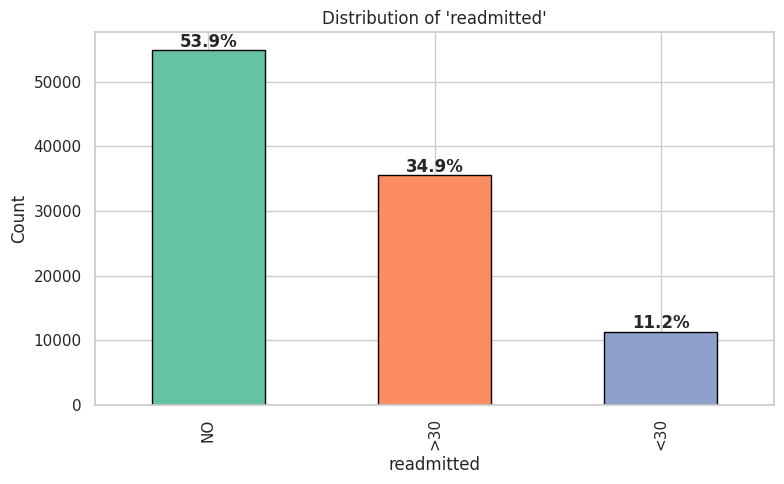

In [15]:
# Original target distribution (before binary conversion)
print('Original readmitted distribution:')
print(df_raw['readmitted'].value_counts())
print()
plot_target_distribution(df_raw, 'readmitted')

---
## 3. Data Cleaning

In [16]:
df = clean_diabetes_data(df_raw)
print(f'\nShape after cleaning: {df.shape}')
print(f'Remaining columns: {df.columns.tolist()}')

Dropped high-null columns: ['weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult']
Dropped zero-variance columns: ['examide', 'citoglipton']
Rows after removing expired/hospice: 99340

Shape after cleaning: (99340, 42)
Remaining columns: ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


Remaining missing values:
payer_code    39397
race           2232
diag_3         1419
diag_2          356
diag_1           20
dtype: int64



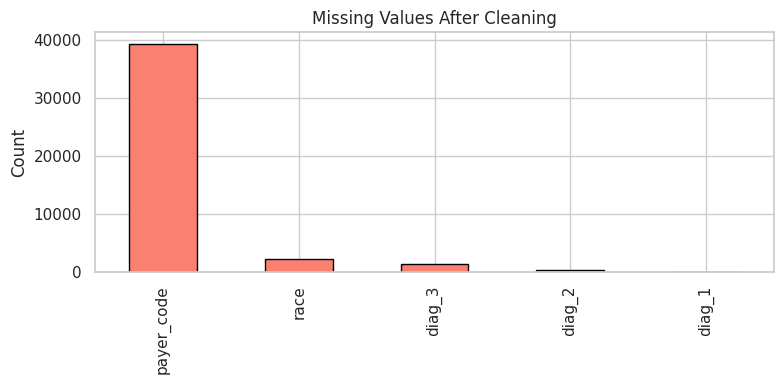

In [17]:
# Check remaining missing values
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
if len(null_counts) > 0:
    print('Remaining missing values:')
    print(null_counts)
    print()
    null_counts.plot.bar(color='salmon', edgecolor='black', figsize=(8, 4))
    plt.title('Missing Values After Cleaning')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values remain!')

---
## 4. Feature Engineering & Binary Target

In [18]:
df = engineer_features(df)
print(f'Shape after feature engineering: {df.shape}')
df.head()

Shape after feature engineering: (99340, 46)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,...,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,total_visits,num_med_changed,num_med_active,age_numeric
0,Caucasian,Female,[0-10),6,25,1,1,NaN,41,0,...,No,No,No,0,0,NO,0,0,0,5
1,Caucasian,Female,[10-20),1,1,7,3,NaN,59,0,...,No,No,No,1,1,>30,0,1,1,15
2,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,11,5,...,No,No,No,0,1,NO,3,0,1,25
3,Caucasian,Male,[30-40),1,1,7,2,NaN,44,1,...,No,No,No,1,1,NO,0,1,1,35
4,Caucasian,Male,[40-50),1,1,7,1,NaN,51,0,...,No,No,No,1,1,NO,0,0,2,45


In [19]:
# Convert readmitted to binary: 1 = readmitted within 30 days, 0 = otherwise
print('Before binary conversion:')
print(df['readmitted'].value_counts())
print()

df = create_binary_target(df, col='readmitted')

print('After binary conversion (1 = readmitted <30 days, 0 = not):')
print(df['readmitted'].value_counts())
print(f'\nPositive class rate: {df["readmitted"].mean():.2%}')

Before binary conversion:
readmitted
NO     52524
>30    35502
<30    11314
Name: count, dtype: int64

After binary conversion (1 = readmitted <30 days, 0 = not):
readmitted
0    88026
1    11314
Name: count, dtype: int64

Positive class rate: 11.39%


In [20]:
# Drop columns no longer needed after feature engineering
drop_cols = [c for c in ['age', 'payer_code'] if c in df.columns]
# Also drop individual medication columns (summarized into num_med_changed/num_med_active)
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
            'rosiglitazone', 'insulin', 'acarbose', 'miglitol',
            'tolbutamide', 'tolazamide', 'troglitazone', 'acetohexamide',
            'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone',
            'metformin-pioglitazone']
drop_cols += [c for c in med_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f'Dropped {len(drop_cols)} columns. Shape: {df.shape}')
print(f'Remaining columns: {df.columns.tolist()}')

Dropped 23 columns. Shape: (99340, 23)
Remaining columns: ['race', 'gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'change', 'diabetesMed', 'readmitted', 'total_visits', 'num_med_changed', 'num_med_active', 'age_numeric']


---
## 5. Exploratory Data Analysis (EDA)

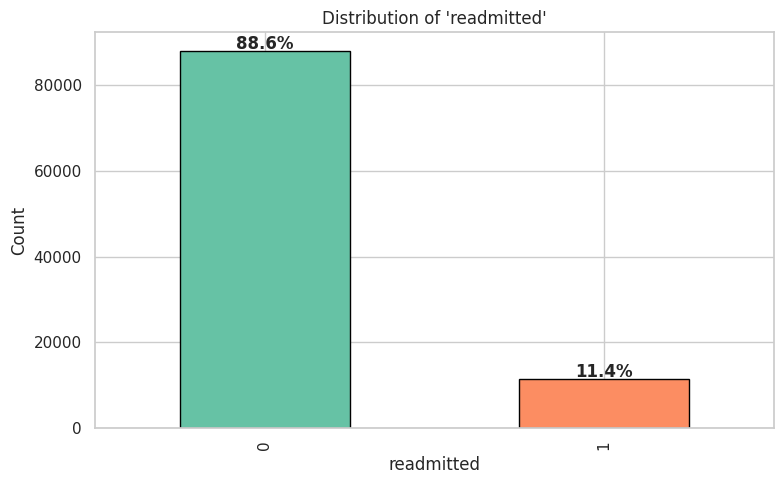

In [21]:
# Binary target distribution
plot_target_distribution(df, 'readmitted')

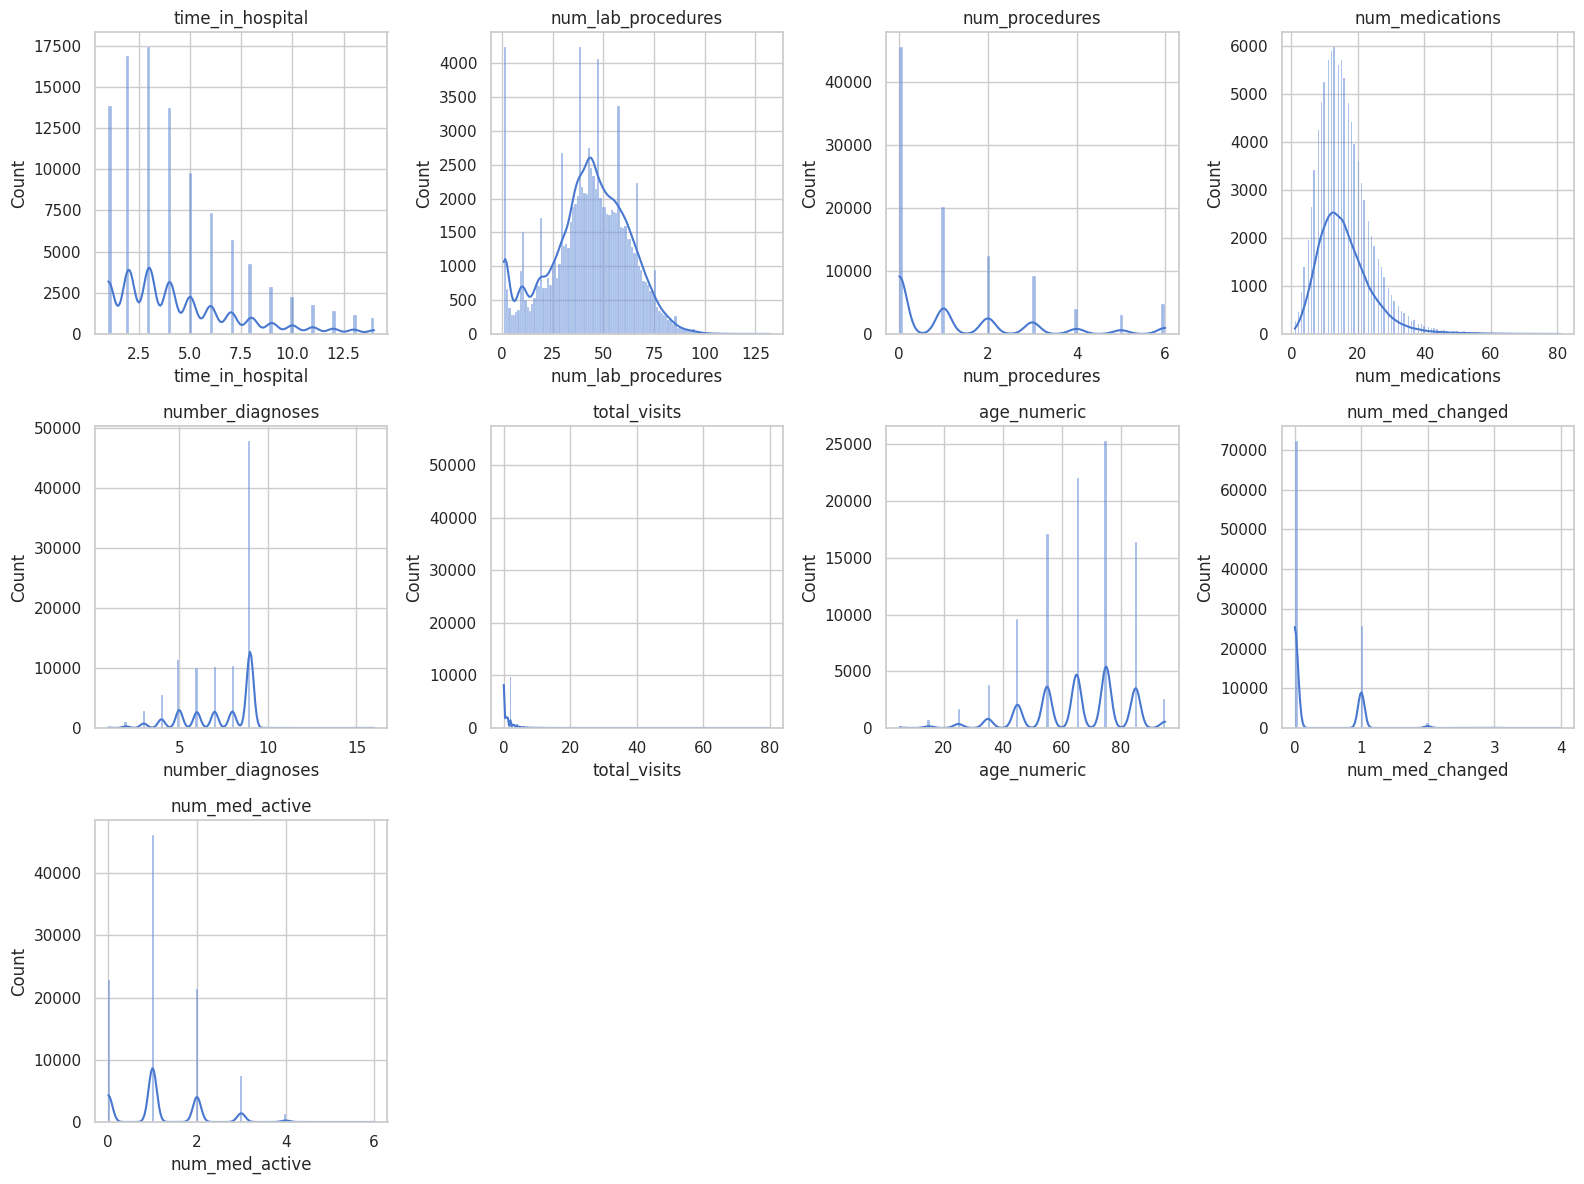

In [22]:
# Numeric feature distributions
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_diagnoses', 'total_visits',
            'age_numeric', 'num_med_changed', 'num_med_active']
plot_distributions(df, cols=num_cols)

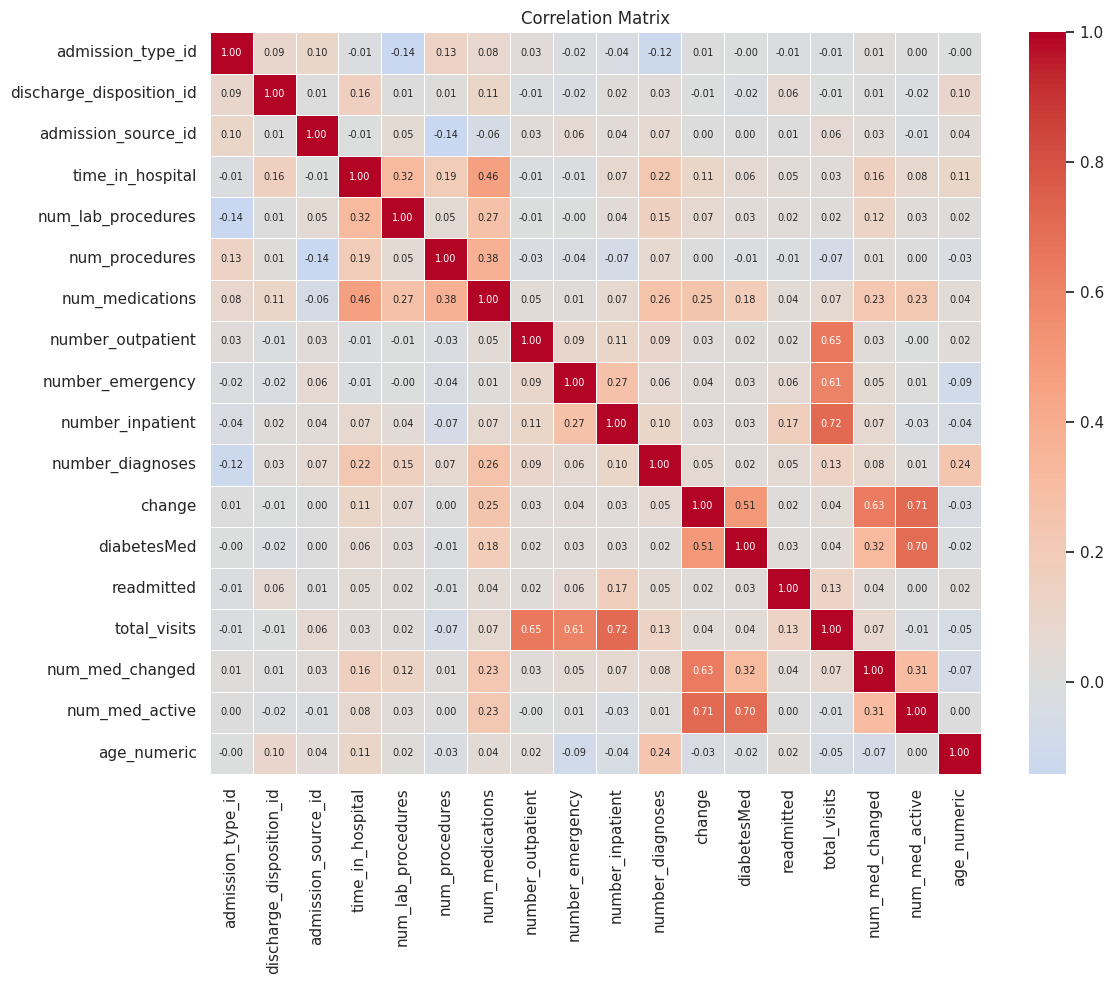

In [23]:
# Correlation matrix for numeric features
plot_correlation_matrix(df)

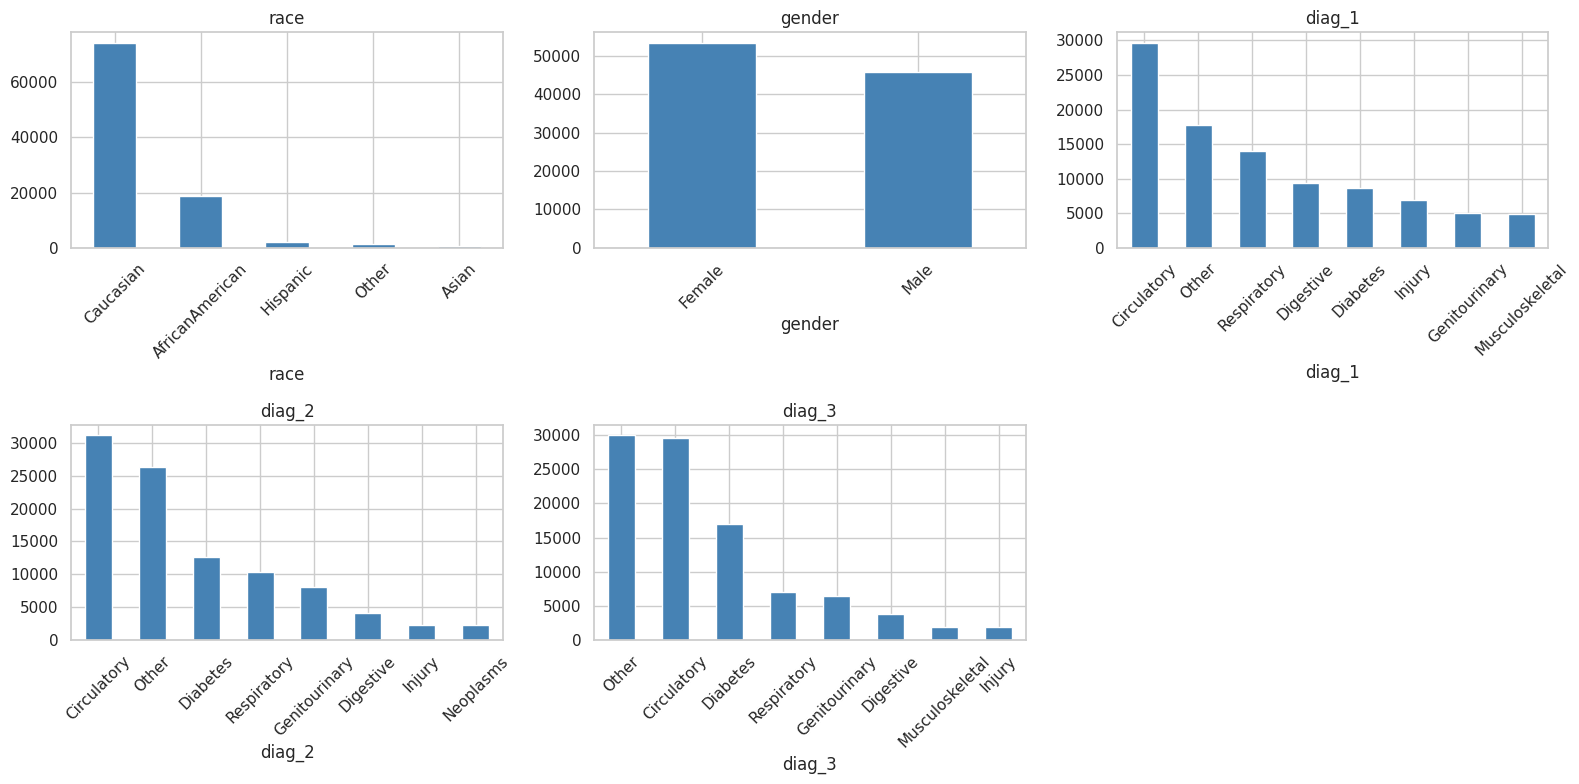

In [24]:
# Categorical feature distributions
cat_cols = [c for c in df.select_dtypes(include='object').columns if c != 'readmitted']
plot_categorical_counts(df, cols=cat_cols[:6], top_n=8)

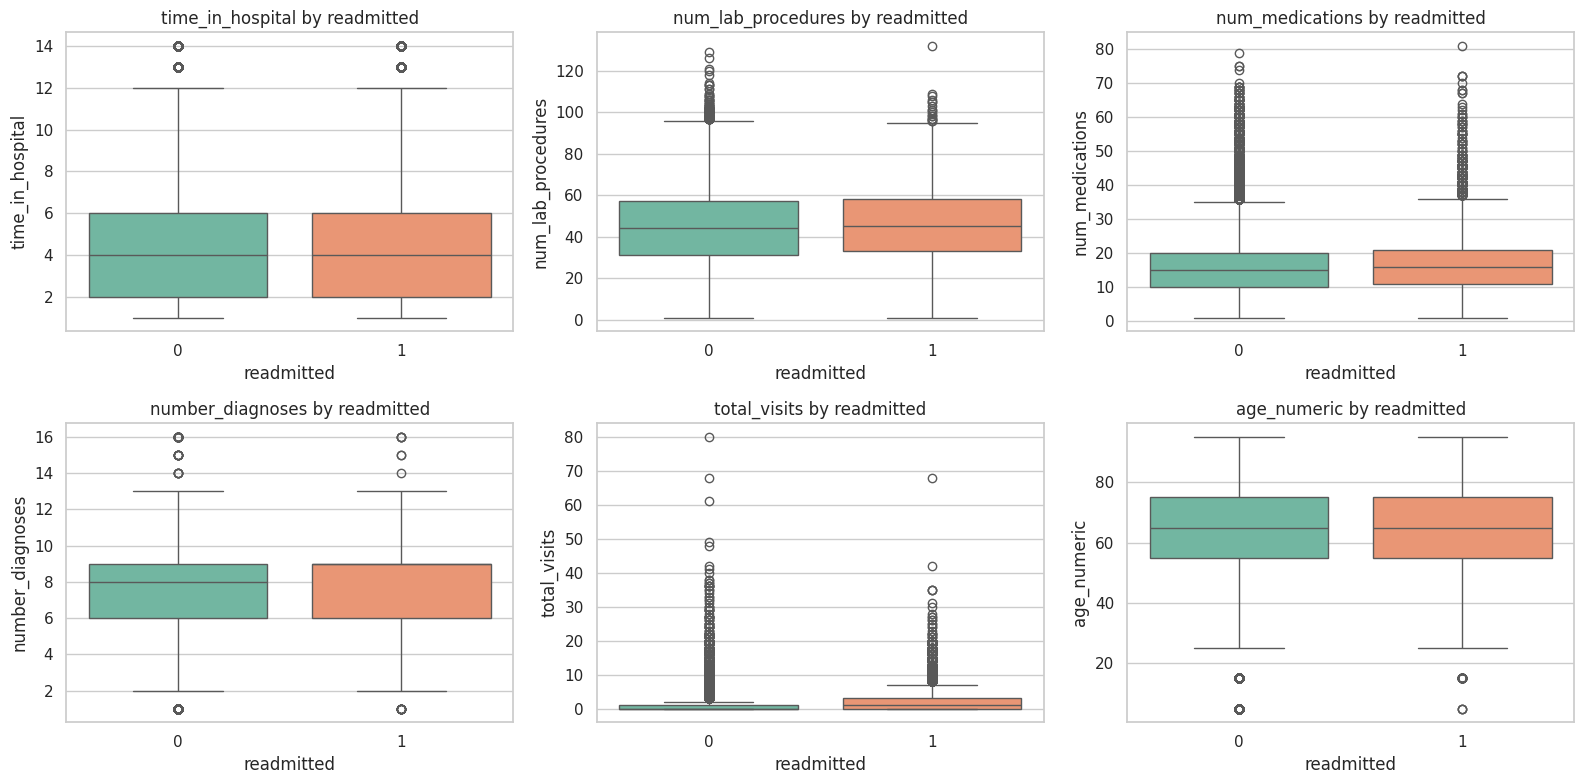

In [25]:
# Features vs target (box plots)
key_features = ['time_in_hospital', 'num_lab_procedures', 'num_medications',
                'number_diagnoses', 'total_visits', 'age_numeric']
plot_target_vs_features(df, target='readmitted', cols=key_features)

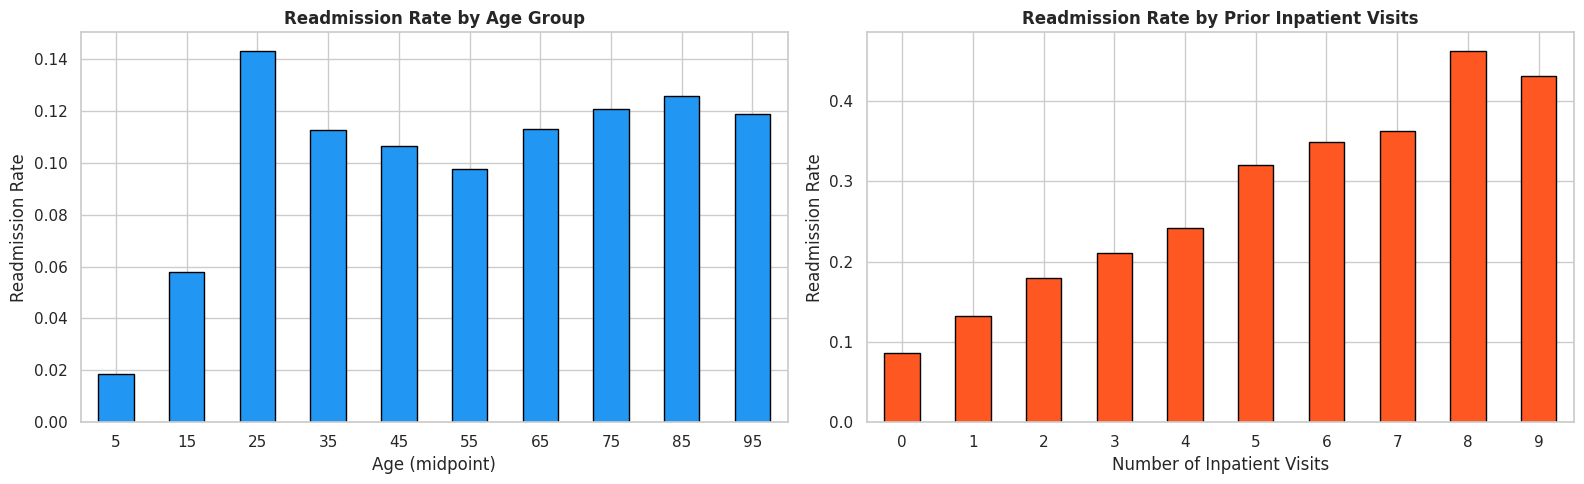

In [26]:
# Readmission rate by age group
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# By age
age_readmit = df.groupby('age_numeric')['readmitted'].mean()
age_readmit.plot.bar(ax=axes[0], color='#2196F3', edgecolor='black')
axes[0].set_title('Readmission Rate by Age Group', fontweight='bold')
axes[0].set_ylabel('Readmission Rate')
axes[0].set_xlabel('Age (midpoint)')
axes[0].tick_params(axis='x', rotation=0)

# By number of inpatient visits
inpatient_readmit = df.groupby('number_inpatient')['readmitted'].mean().head(10)
inpatient_readmit.plot.bar(ax=axes[1], color='#FF5722', edgecolor='black')
axes[1].set_title('Readmission Rate by Prior Inpatient Visits', fontweight='bold')
axes[1].set_ylabel('Readmission Rate')
axes[1].set_xlabel('Number of Inpatient Visits')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 6. Statistical Tests

In [27]:
# Normality test on key numeric features
print('=== Normality Tests (Shapiro-Wilk) ===')
for col in ['time_in_hospital', 'num_lab_procedures', 'num_medications']:
    print(f'\n{col}:')
    normality_test(df[col])

=== Normality Tests (Shapiro-Wilk) ===

time_in_hospital:
Shapiro-Wilk: stat=0.8858, p=0.0000 -> not normal (a=0.05)

num_lab_procedures:
Shapiro-Wilk: stat=0.9842, p=0.0000 -> not normal (a=0.05)

num_medications:
Shapiro-Wilk: stat=0.9264, p=0.0000 -> not normal (a=0.05)


In [28]:
# Correlation tests
print('=== Correlation: num_medications vs num_lab_procedures ===')
correlation_test(df['num_medications'], df['num_lab_procedures'])

=== Correlation: num_medications vs num_lab_procedures ===
Pearson:  r=0.2652, p=0.0000
Spearman: r=0.2484, p=0.0000


{'pearson': (np.float64(0.2651635792723711), np.float64(0.0)),
 'spearman': (np.float64(0.24842478558228442), np.float64(0.0))}

In [29]:
# Chi-squared: readmitted vs diagnosis category
print('=== Chi-squared: readmitted vs diag_1 ===')
# Need to use the pre-binary version for chi2
chi2_test(df, 'diag_1', 'readmitted')

print('\n=== Chi-squared: readmitted vs gender ===')
chi2_test(df, 'gender', 'readmitted')

=== Chi-squared: readmitted vs diag_1 ===
Chi2=81.96, p=0.0000, dof=8 -> dependent (a=0.05)

=== Chi-squared: readmitted vs gender ===
Chi2=0.63, p=0.4284, dof=1 -> independent (a=0.05)


(np.float64(0.6272251034884233), np.float64(0.42837499474371954), 1)

---
## 7. Preprocessing (Encoding, Splitting, SMOTE, Scaling)

Pipeline:
1. One-hot encode categoricals + drop high-cardinality columns
2. Stratified train/test split (80/20)
3. Apply SMOTE **on training set only** to address class imbalance
4. StandardScaler on all features

In [30]:
# Encode and split
X_train, X_test, y_train, y_test, feature_names, scaler = encode_and_prepare(
    df, target='readmitted', test_size=0.2, random_state=42
)
print(f'\nBefore SMOTE:')
print(f'  X_train: {X_train.shape}, y_train distribution: {dict(y_train.value_counts())}')
print(f'  X_test:  {X_test.shape},  y_test distribution:  {dict(y_test.value_counts())}')

Final feature matrix shape: (99340, 46)

Before SMOTE:
  X_train: (79472, 46), y_train distribution: {0: np.int64(70421), 1: np.int64(9051)}
  X_test:  (19868, 46),  y_test distribution:  {0: np.int64(17605), 1: np.int64(2263)}


In [31]:
# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'After SMOTE:')
print(f'  X_train: {X_train_sm.shape}, y_train distribution: {dict(pd.Series(y_train_sm).value_counts())}')
print(f'  X_test:  {X_test.shape} (unchanged — no SMOTE on test set)')

After SMOTE:
  X_train: (140842, 46), y_train distribution: {0: np.int64(70421), 1: np.int64(70421)}
  X_test:  (19868, 46) (unchanged — no SMOTE on test set)


---
## 8. Model Training & Hyperparameter Tuning

We train three classifiers on the SMOTE-balanced training data:
- **Logistic Regression** (linear baseline)
- **Random Forest** (ensemble, bagging)
- **XGBoost** (ensemble, boosting)

For each model, we use **GridSearchCV** (3-fold, ROC-AUC scoring) to search over a reasonable parameter grid instead of relying on hardcoded defaults. The best estimator from each search is kept for evaluation.

In [ ]:
# --- Logistic Regression ---
lr_params = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs'], 'max_iter': [1000]}
lr_search = GridSearchCV(
    LogisticRegression(random_state=42), lr_params,
    scoring='roc_auc', cv=3, n_jobs=-1
)
lr_search.fit(X_train_sm, y_train_sm)
lr = lr_search.best_estimator_
print(f'LR best params: {lr_search.best_params_}')
print(f'   CV ROC-AUC:  {lr_search.best_score_:.4f}')

# --- Random Forest ---
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10]
}
rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1), rf_params,
    scoring='roc_auc', cv=3, n_jobs=-1
)
rf_search.fit(X_train_sm, y_train_sm)
rf = rf_search.best_estimator_
print(f'RF best params: {rf_search.best_params_}')
print(f'   CV ROC-AUC:  {rf_search.best_score_:.4f}')

# --- XGBoost ---
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2]
}
xgb_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1), xgb_params,
    scoring='roc_auc', cv=3, n_jobs=-1
)
xgb_search.fit(X_train_sm, y_train_sm)
xgb = xgb_search.best_estimator_
print(f'XGB best params: {xgb_search.best_params_}')
print(f'    CV ROC-AUC:  {xgb_search.best_score_:.4f}')

print('\nAll three models trained with tuned hyperparameters.')

**Tuning Summary:** GridSearchCV tested multiple parameter combinations for each model using 3-fold cross-validation on the SMOTE-balanced training set. The best parameters found above are now used for all downstream evaluation, explainability, and deployment.

In [ ]:
# quick summary of what GridSearchCV picked
import pandas as pd
tuning_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Best Params': [str(lr_search.best_params_), str(rf_search.best_params_), str(xgb_search.best_params_)],
    'CV ROC-AUC': [lr_search.best_score_, rf_search.best_score_, xgb_search.best_score_]
})
tuning_df.style.format({'CV ROC-AUC': '{:.4f}'})

---
## 9. Model Evaluation & Comparison

In [33]:
# Evaluate each model on the held-out test set
label_names = ['Not Readmitted', 'Readmitted <30d']

results = {}
trained_models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb
}

for name, model in trained_models.items():
    print(f'\n{"=" * 50}')
    print(f'  {name}')
    print(f'{"=" * 50}')
    results[name] = evaluate_classifier(model, X_test, y_test, label_names)


  Logistic Regression
                 precision    recall  f1-score   support

 Not Readmitted       0.92      0.65      0.76     17605
Readmitted <30d       0.17      0.55      0.26      2263

       accuracy                           0.64     19868
      macro avg       0.54      0.60      0.51     19868
   weighted avg       0.83      0.64      0.71     19868


  Random Forest
                 precision    recall  f1-score   support

 Not Readmitted       0.89      0.99      0.94     17605
Readmitted <30d       0.35      0.06      0.10      2263

       accuracy                           0.88     19868
      macro avg       0.62      0.52      0.52     19868
   weighted avg       0.83      0.88      0.84     19868


  XGBoost
                 precision    recall  f1-score   support

 Not Readmitted       0.89      1.00      0.94     17605
Readmitted <30d       0.51      0.02      0.04      2263

       accuracy                           0.89     19868
      macro avg       0.70   

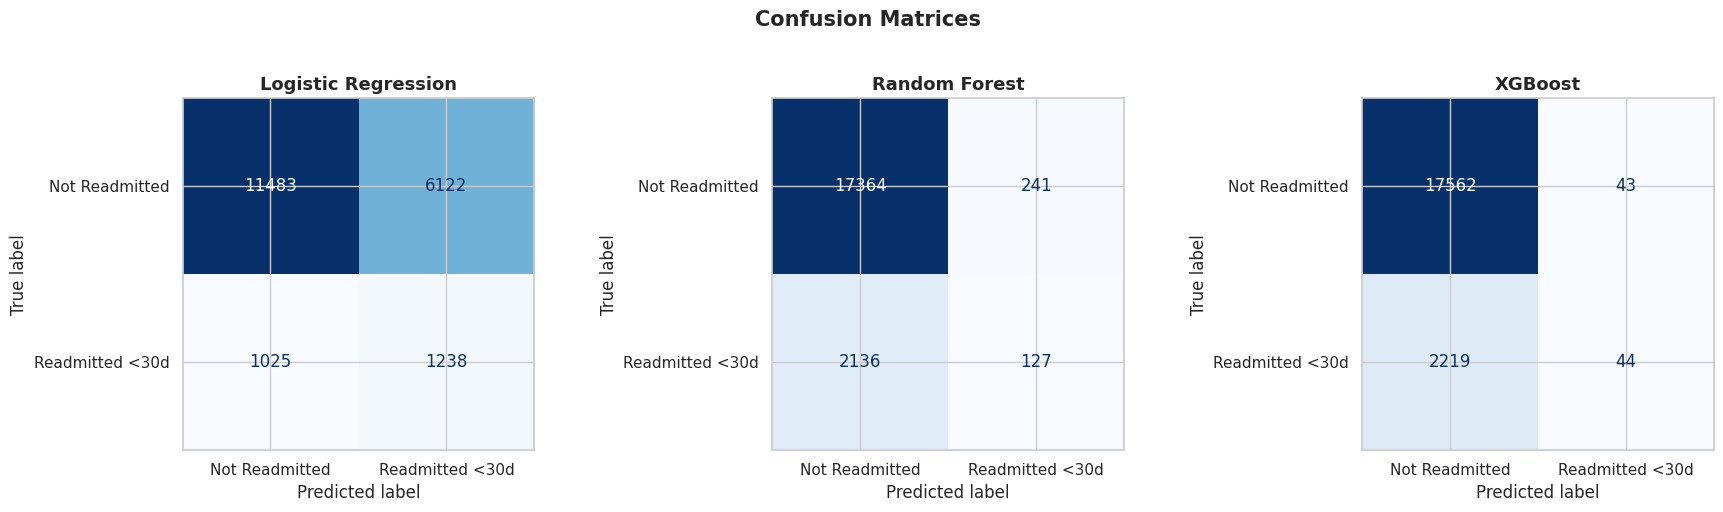

In [34]:
# Side-by-side confusion matrices
plot_confusion_matrices(trained_models, X_test, y_test, label_names)

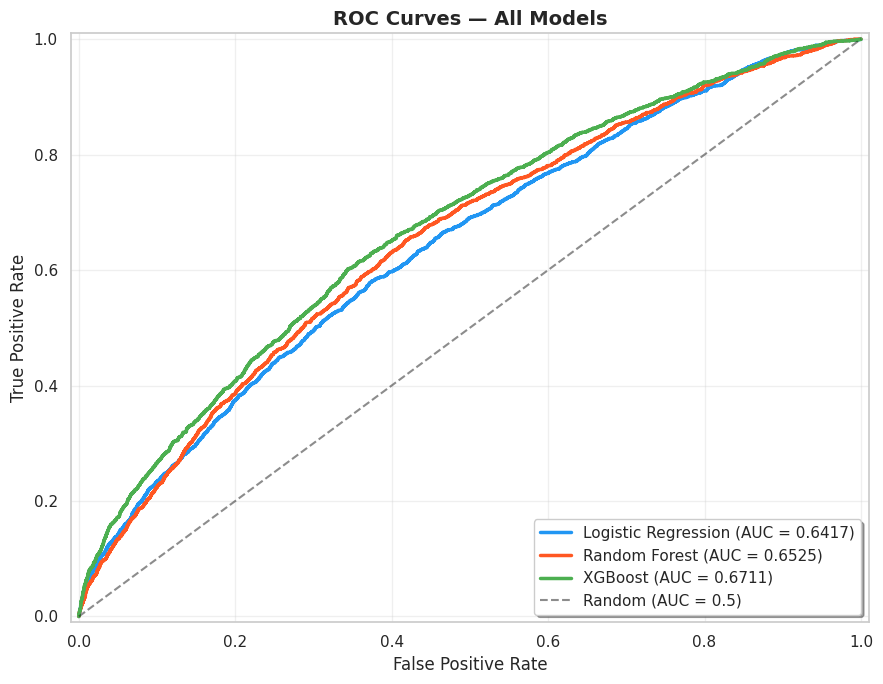

In [35]:
# === ROC Curves (all 3 models on one plot) ===
plot_roc_curves(trained_models, X_test, y_test)

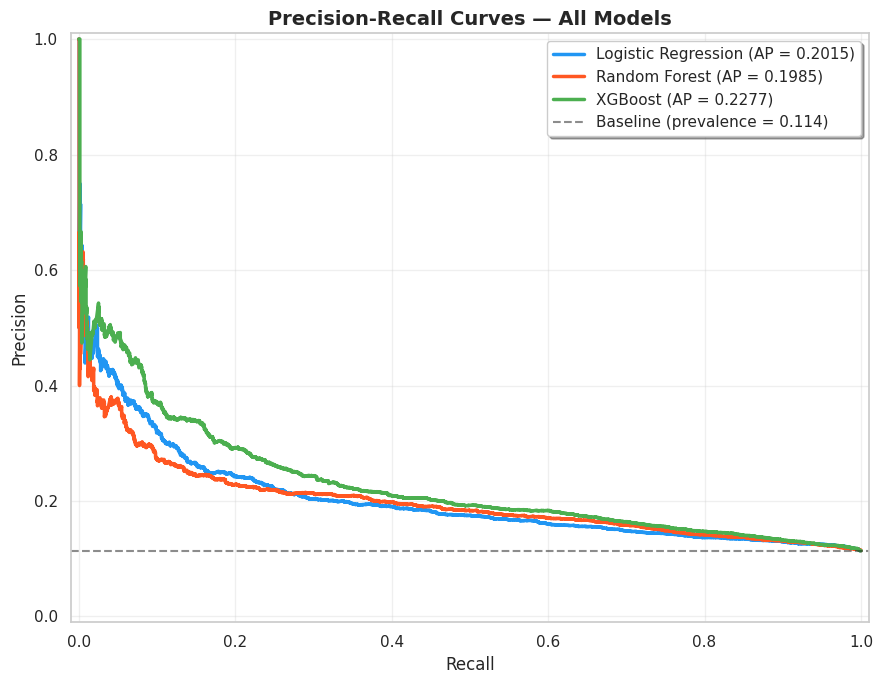

In [36]:
# === Precision-Recall Curves (all 3 models on one plot) ===
plot_precision_recall_curves(trained_models, X_test, y_test)

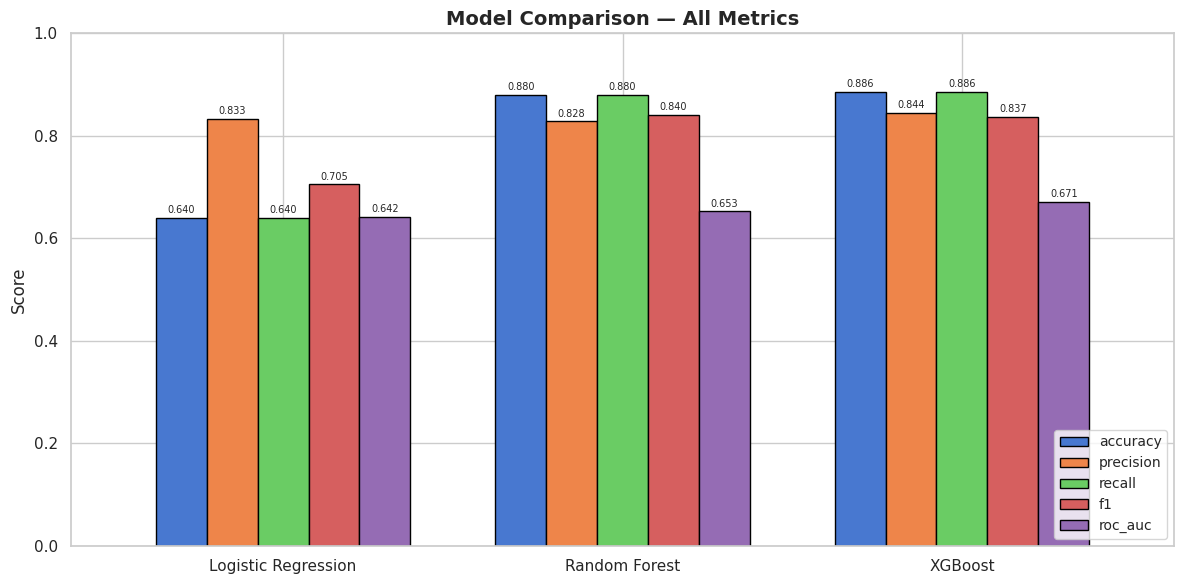

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.640276,0.832644,0.640276,0.705099,0.641710
Random Forest,0.880360,0.828345,0.880360,0.840330,0.652529
XGBoost,0.886149,0.844303,0.886149,0.836751,0.671134


In [37]:
# Metric comparison bar chart
df_results = compare_models(results)
df_results

=== 5-Fold Stratified Cross-Validation ===
Logistic Regression       CV roc_auc: 0.6543 (+/- 0.0019)
Random Forest             CV roc_auc: 0.9600 (+/- 0.0015)
XGBoost                   CV roc_auc: 0.9576 (+/- 0.0015)


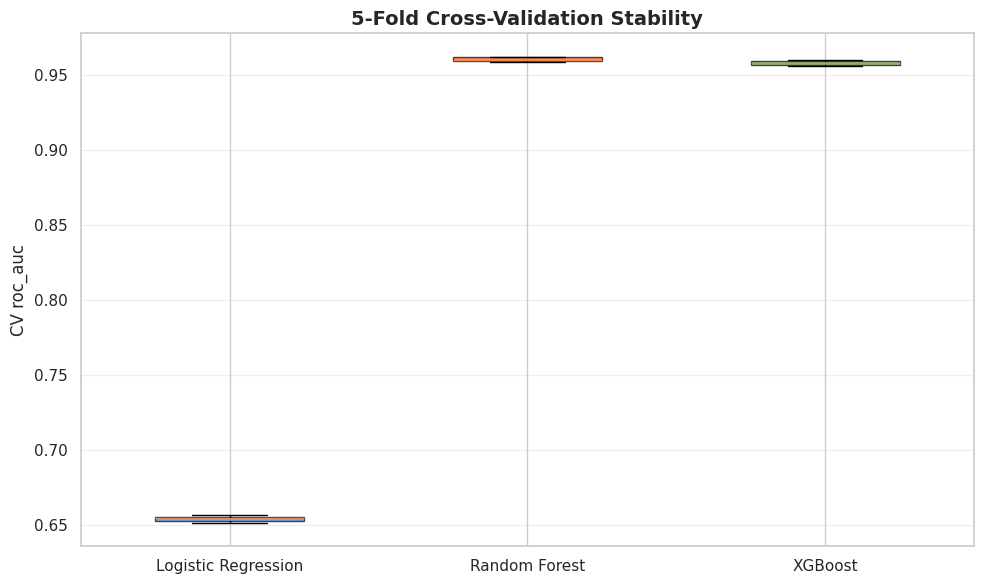

In [38]:
# Cross-validation stability (box plot)
print('=== 5-Fold Stratified Cross-Validation ===')
cv_scores = cross_val_box_plot(trained_models, X_train_sm, y_train_sm,
                                cv=5, scoring='roc_auc')

---
## 10. Best Model Selection

> *"The best-performing and most stable model will be chosen for the explainability analysis."*

Selection criteria:
- Highest ROC-AUC on the test set
- Lowest CV standard deviation (stability)
- Best F1 score

In [39]:
# Build a selection summary
selection = pd.DataFrame({
    'Test ROC-AUC': {name: results[name]['roc_auc'] for name in trained_models},
    'Test F1': {name: results[name]['f1'] for name in trained_models},
    'CV ROC-AUC Mean': {name: cv_scores[name].mean() for name in trained_models},
    'CV ROC-AUC Std': {name: cv_scores[name].std() for name in trained_models},
})
selection['Stability (1 - Std)'] = 1 - selection['CV ROC-AUC Std']

print('=== Model Selection Summary ===')
print(selection.round(4).to_string())

# Select the model with the best ROC-AUC
best_name = selection['Test ROC-AUC'].idxmax()
best_model = trained_models[best_name]
print(f'\n>>> Best model selected: {best_name} (Test ROC-AUC = {selection.loc[best_name, "Test ROC-AUC"]:.4f})')

=== Model Selection Summary ===
                     Test ROC-AUC  Test F1  CV ROC-AUC Mean  CV ROC-AUC Std  Stability (1 - Std)
Logistic Regression        0.6417   0.7051           0.6543          0.0019               0.9981
Random Forest              0.6525   0.8403           0.9600          0.0015               0.9985
XGBoost                    0.6711   0.8368           0.9576          0.0015               0.9985

>>> Best model selected: XGBoost (Test ROC-AUC = 0.6711)


---
## 11. Explainability — Permutation Feature Importance (PFI)

PFI measures how much the model's ROC-AUC drops when each feature is randomly shuffled.  
Applied **only on the selected best model**.

Computing PFI for: XGBoost


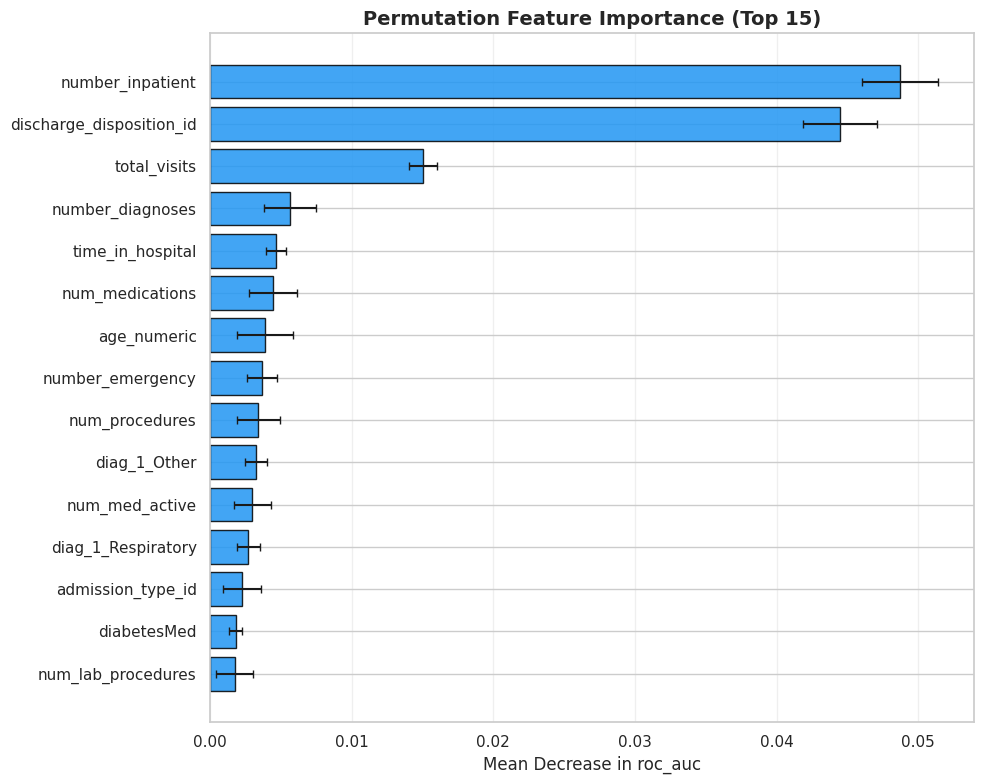


Top 10 most important features:


,feature,importance_mean,importance_std
9,number_inpatient,0.048680,0.002682
1,discharge_disposition_id,0.044466,0.002607
13,total_visits,0.015030,0.000971
10,number_diagnoses,0.005660,0.001813
3,time_in_hospital,0.004661,0.000733
6,num_medications,0.004467,0.001686
16,age_numeric,0.003874,0.001971
8,number_emergency,0.003652,0.001062
5,num_procedures,0.003425,0.001521
28,diag_1_Other,0.003252,0.000806


In [40]:
print(f'Computing PFI for: {best_name}')
pfi_results = plot_permutation_importance(
    best_model, X_test, y_test,
    feature_names=feature_names,
    top_n=15, n_repeats=10, scoring='roc_auc'
)
print('\nTop 10 most important features:')
pfi_results.head(10)

---
## 12. Explainability — Partial Dependence Plots (PDP)

PDP shows the marginal effect of a feature on the predicted probability.  
We plot the top features identified by PFI.

PDP for: XGBoost
Features: ['number_inpatient', 'discharge_disposition_id', 'total_visits', 'number_diagnoses', 'time_in_hospital', 'num_medications']


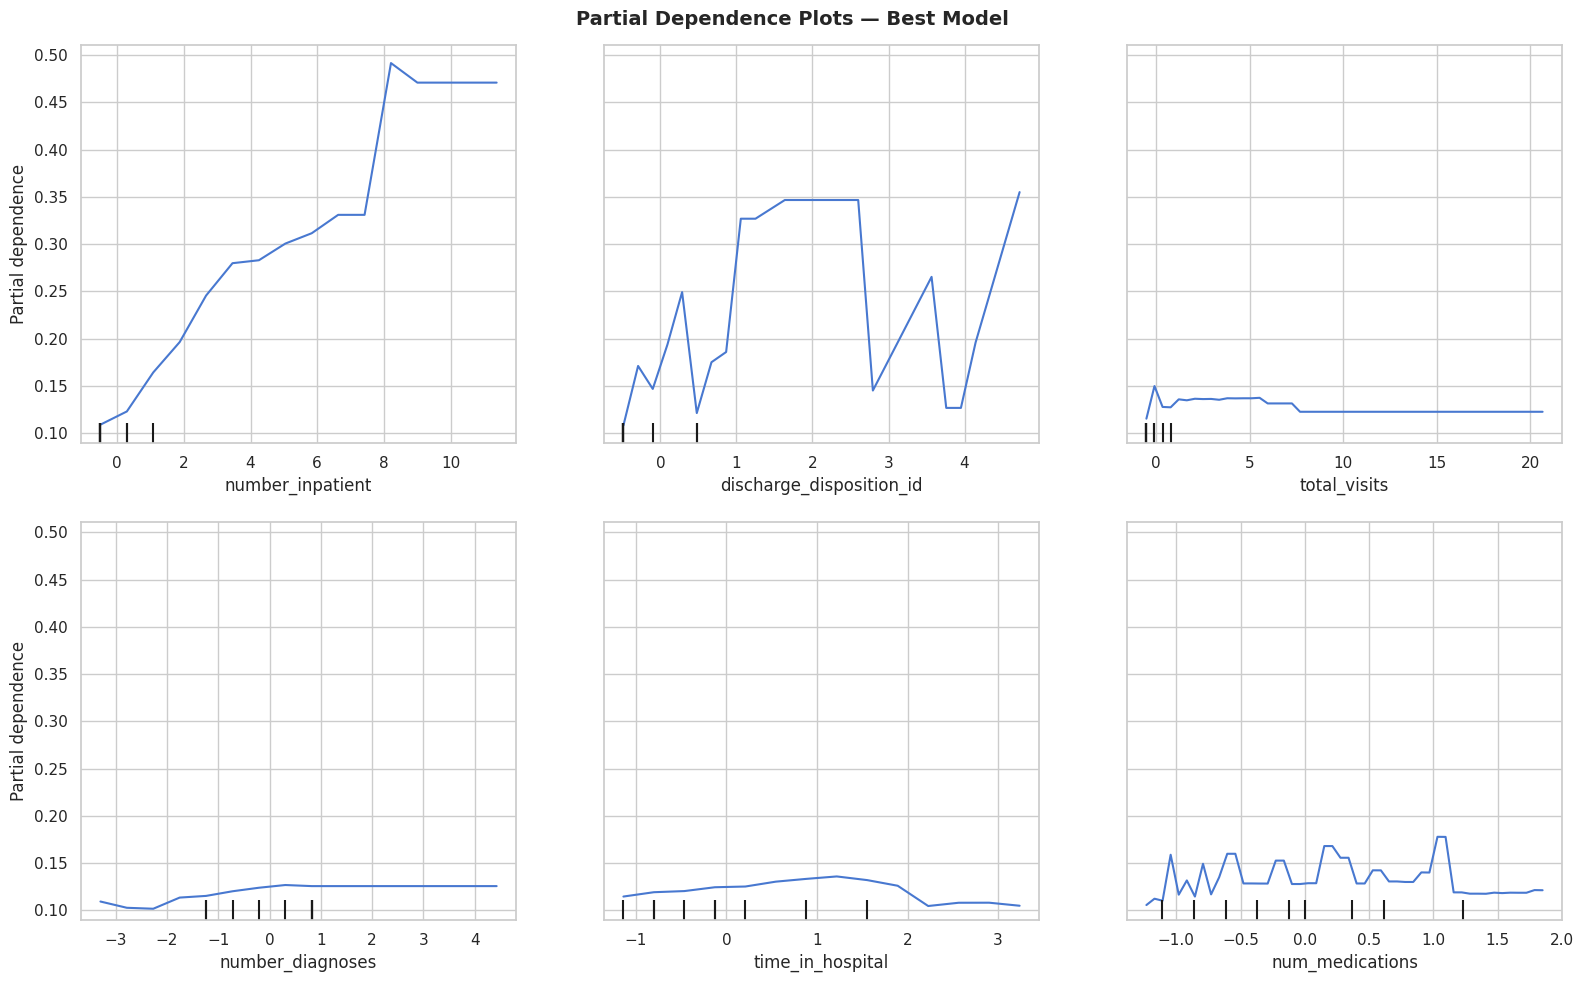

In [41]:
# Get the top features from PFI (only numeric / meaningful ones)
top_features = pfi_results['feature'].head(6).tolist()

# Find their indices in feature_names
feature_indices = [feature_names.index(f) for f in top_features if f in feature_names]

print(f'PDP for: {best_name}')
print(f'Features: {[feature_names[i] for i in feature_indices]}')

plot_partial_dependence(
    best_model, X_test,
    features=feature_indices,
    feature_names=feature_names
)

---
## 13. Classification Threshold Analysis

The default threshold of 0.5 may not be optimal for imbalanced data.  
We sweep thresholds and find the one that maximizes F1.

Threshold analysis for: XGBoost


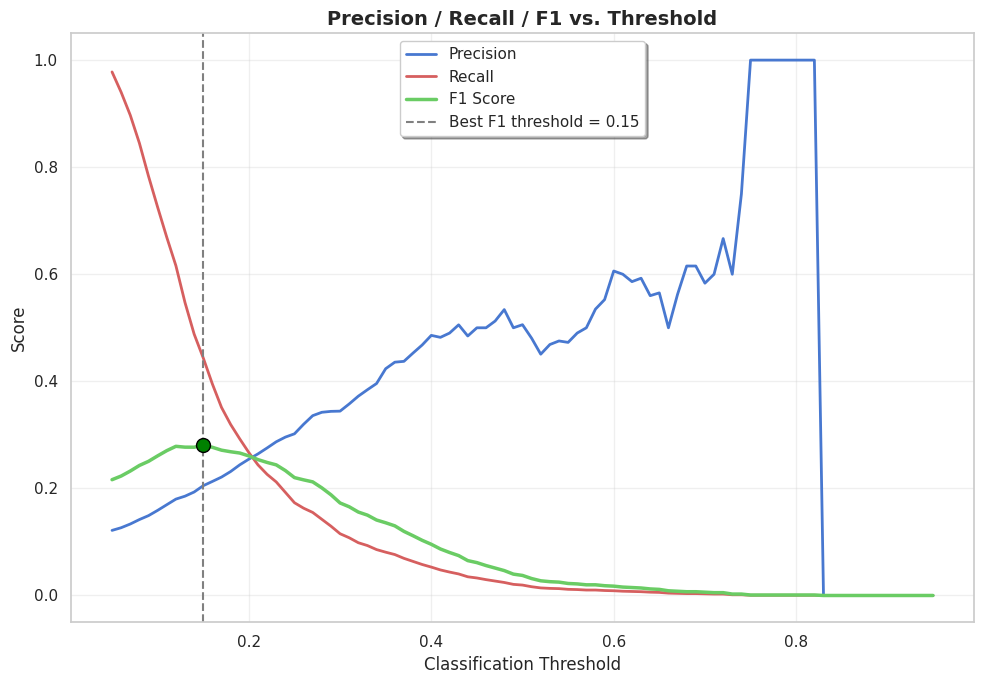

Optimal threshold (max F1): 0.15
  Precision: 0.2051
  Recall:    0.4437
  F1 Score:  0.2805


In [42]:
print(f'Threshold analysis for: {best_name}')
optimal_threshold = threshold_analysis(best_model, X_test, y_test)

In [43]:
# Compare default vs optimal threshold
from sklearn.metrics import classification_report as cr

y_prob = best_model.predict_proba(X_test)[:, 1]

print(f'=== Default Threshold (0.50) ===')
y_pred_default = (y_prob >= 0.50).astype(int)
print(cr(y_test, y_pred_default, target_names=label_names))

print(f'\n=== Optimal Threshold ({optimal_threshold:.2f}) ===')
y_pred_optimal = (y_prob >= optimal_threshold).astype(int)
print(cr(y_test, y_pred_optimal, target_names=label_names))

=== Default Threshold (0.50) ===
                 precision    recall  f1-score   support

 Not Readmitted       0.89      1.00      0.94     17605
Readmitted <30d       0.51      0.02      0.04      2263

       accuracy                           0.89     19868
      macro avg       0.70      0.51      0.49     19868
   weighted avg       0.84      0.89      0.84     19868


=== Optimal Threshold (0.15) ===
                 precision    recall  f1-score   support

 Not Readmitted       0.92      0.78      0.84     17605
Readmitted <30d       0.21      0.44      0.28      2263

       accuracy                           0.74     19868
      macro avg       0.56      0.61      0.56     19868
   weighted avg       0.83      0.74      0.78     19868



---
## 14. Sample Predictions — Actual vs Predicted (Live Demo)

This section demonstrates the model's predictions on **real patients from the held-out test set**.  
Each row shows key clinical features, the model's predicted probability, risk level, and whether the prediction matched reality. This provides a concrete sense of how the model performs on individual patients — a preview of what the explainability interface will deliver.

In [44]:
# Select 20 diverse patients from the test set
np.random.seed(42)
sample_idx = np.random.choice(X_test.index, size=20, replace=False)

# Predict
sample_probs = best_model.predict_proba(X_test.loc[sample_idx])[:, 1]
sample_preds = (sample_probs >= optimal_threshold).astype(int)
sample_actual = y_test.loc[sample_idx].values

# Build display table with readable clinical features
sample_table = pd.DataFrame({
    'Age': df.loc[sample_idx, 'age_numeric'].values.astype(int),
    'Days in Hospital': df.loc[sample_idx, 'time_in_hospital'].values.astype(int),
    'Medications': df.loc[sample_idx, 'num_medications'].values.astype(int),
    'Inpatient Visits': df.loc[sample_idx, 'number_inpatient'].values.astype(int),
    'Diagnoses': df.loc[sample_idx, 'number_diagnoses'].values.astype(int),
    'Actual': sample_actual,
    'Pred Probability': np.round(sample_probs, 3),
    'Predicted': sample_preds,
    'Risk Level': ['HIGH' if p >= 0.30 else ('MEDIUM' if p >= optimal_threshold else 'LOW')
                   for p in sample_probs],
    'Correct': ['Yes' if a == p else 'No' for a, p in zip(sample_actual, sample_preds)]
})
sample_table.index = range(1, 21)
sample_table.index.name = 'Patient'

# Color-coded styled table
def color_risk(val):
    if val == 'HIGH':
        return 'background-color: #FFCDD2; color: #B71C1C; font-weight: bold'
    elif val == 'MEDIUM':
        return 'background-color: #FFE0B2; color: #E65100; font-weight: bold'
    return 'background-color: #C8E6C9; color: #1B5E20; font-weight: bold'

def color_correct(val):
    if val == 'Yes':
        return 'background-color: #C8E6C9; font-weight: bold'
    return 'background-color: #FFCDD2; font-weight: bold'

styled = (sample_table.style
    .applymap(color_risk, subset=['Risk Level'])
    .applymap(color_correct, subset=['Correct'])
    .format({'Pred Probability': '{:.3f}'})
    .set_caption(f'Sample Predictions — {best_name} (threshold = {optimal_threshold:.2f})')
)
styled

,Age,Days in Hospital,Medications,Inpatient Visits,Diagnoses,Actual,Pred Probability,Predicted,Risk Level,Correct
Patient,,,,,,,,,,
1,75,5,11,0,8,0,0.101,0,LOW,Yes
2,55,6,21,0,8,0,0.101,0,LOW,Yes
3,45,6,16,3,6,1,0.238,1,MEDIUM,Yes
4,75,3,11,0,8,0,0.062,0,LOW,Yes
5,75,2,7,2,9,0,0.154,1,MEDIUM,No
6,75,9,16,1,9,0,0.143,0,LOW,Yes
7,65,4,16,1,6,1,0.169,1,MEDIUM,Yes
8,85,4,15,0,8,0,0.104,0,LOW,Yes
9,55,10,16,0,8,0,0.034,0,LOW,Yes


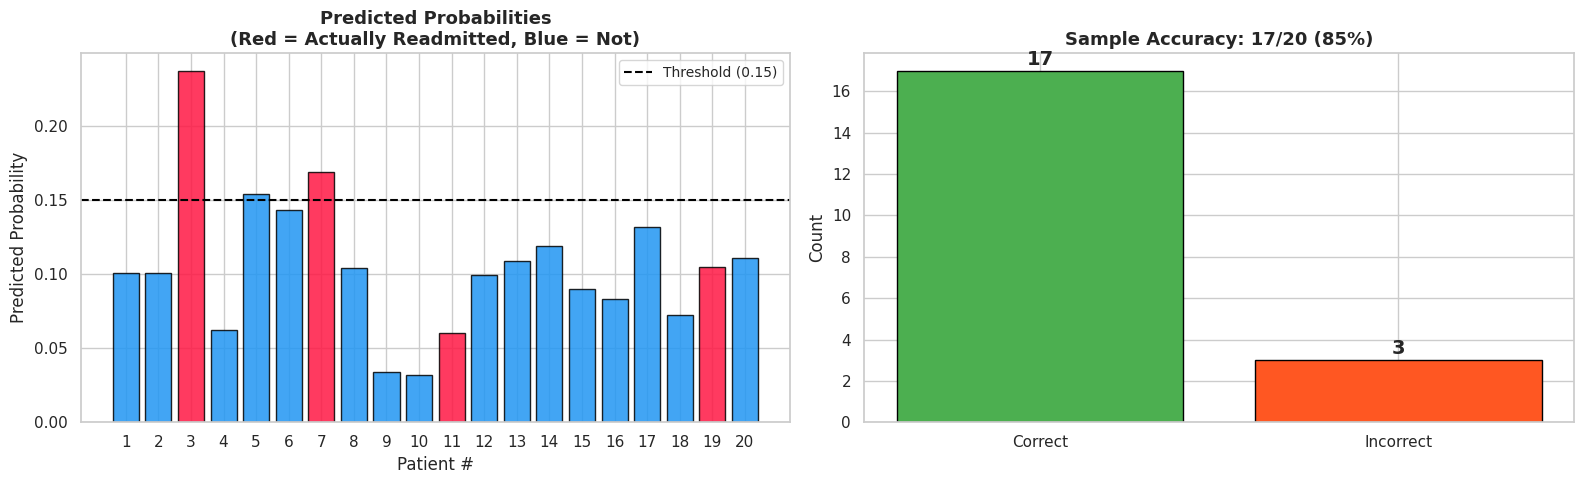

In [45]:
# Visual: predicted probabilities with actual labels color-coded
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Predicted probabilities bar chart
colors = ['#FF1744' if a == 1 else '#2196F3' for a in sample_actual]
axes[0].bar(range(1, 21), sample_probs, color=colors, edgecolor='black', alpha=0.85)
axes[0].axhline(y=optimal_threshold, color='black', linestyle='--', lw=1.5,
                label=f'Threshold ({optimal_threshold:.2f})')
axes[0].set_xlabel('Patient #', fontsize=12)
axes[0].set_ylabel('Predicted Probability', fontsize=12)
axes[0].set_title('Predicted Probabilities\n(Red = Actually Readmitted, Blue = Not)',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xticks(range(1, 21))

# Accuracy summary for sample
correct_count = sum(1 for a, p in zip(sample_actual, sample_preds) if a == p)
incorrect_count = 20 - correct_count
bars = axes[1].bar(['Correct', 'Incorrect'], [correct_count, incorrect_count],
                    color=['#4CAF50', '#FF5722'], edgecolor='black')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title(f'Sample Accuracy: {correct_count}/20 ({correct_count/20:.0%})',
                  fontsize=13, fontweight='bold')
for i, v in enumerate([correct_count, incorrect_count]):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

---
## 15. Patient Risk Assessment — Interactive Prediction

This section implements the **Example Workflow** from the project proposal: given simplified patient inputs, produce a prediction with probability, binary outcome, and top contributing features.

> **Design intent:** This `predict_patient()` function is the backend logic for the visualization interface described in the project plan. In the final deliverable, it will be wrapped in an interactive dashboard (e.g., Streamlit / Gradio) where clinicians can adjust patient parameters via sliders, see risk predictions update in real-time, and explore which features drive the prediction — enabling the user to *contribute to explainability* through interactive exploration.

### Inputs (simplified clinical values):
| Parameter | Description | Default |
|-----------|-------------|---------|
| `age_group` | Patient age midpoint (5–95) | 65 |
| `number_inpatient` | Prior inpatient visits | 0 |
| `num_medications` | Medications during encounter | 15 |
| `time_in_hospital` | Length of stay (days) | 4 |
| `number_diagnoses` | Number of diagnoses coded | 7 |
| `discharge_disposition_id` | Discharge destination (1=Home) | 1 |

### Outputs:
- Predicted probability of readmission
- Binary prediction (0 or 1)
- Risk level (LOW / MEDIUM / HIGH)
- Top contributing features with comparison to population averages
- Visual risk gauge

In [46]:
def predict_patient(age_group=65, number_inpatient=0, num_medications=15,
                    time_in_hospital=4, number_diagnoses=7, number_emergency=0,
                    number_outpatient=0, num_procedures=1, num_lab_procedures=44,
                    discharge_disposition_id=1, admission_type_id=1,
                    admission_source_id=7, race='Caucasian', gender='Female',
                    diag_1='Circulatory', diag_2='Circulatory', diag_3='Other'):
    """
    Predict readmission risk for a single patient encounter.

    Returns dict with probability, prediction, and risk_level.
    """
    # --- Build raw feature values ---
    raw_numeric = {
        'admission_type_id': admission_type_id,
        'discharge_disposition_id': discharge_disposition_id,
        'admission_source_id': admission_source_id,
        'time_in_hospital': time_in_hospital,
        'num_lab_procedures': num_lab_procedures,
        'num_procedures': num_procedures,
        'num_medications': num_medications,
        'number_outpatient': number_outpatient,
        'number_emergency': number_emergency,
        'number_inpatient': number_inpatient,
        'number_diagnoses': number_diagnoses,
        'change': int(df['change'].median()),
        'diabetesMed': int(df['diabetesMed'].median()),
        'total_visits': number_outpatient + number_emergency + number_inpatient,
        'num_med_changed': int(df['num_med_changed'].median()),
        'num_med_active': int(df['num_med_active'].median()),
        'age_numeric': age_group,
    }
    categorical = {
        'race': race, 'gender': gender,
        'diag_1': diag_1, 'diag_2': diag_2, 'diag_3': diag_3,
    }

    # --- Create encoded feature vector (matching training format) ---
    patient_encoded = pd.DataFrame(0, index=[0], columns=feature_names, dtype=float)

    for col, val in raw_numeric.items():
        if col in feature_names:
            patient_encoded[col] = val

    for col, val in categorical.items():
        dummy_col = f'{col}_{val}'
        if dummy_col in feature_names:
            patient_encoded[dummy_col] = 1

    # --- Scale with training scaler ---
    patient_scaled = pd.DataFrame(
        scaler.transform(patient_encoded), columns=feature_names
    )

    # --- Predict ---
    prob = best_model.predict_proba(patient_scaled)[0, 1]
    pred = int(prob >= optimal_threshold)

    if prob >= 0.30:
        risk, color = 'HIGH RISK', '#FF1744'
    elif prob >= optimal_threshold:
        risk, color = 'MEDIUM RISK', '#FF9100'
    else:
        risk, color = 'LOW RISK', '#00C853'

    # ====== DISPLAY: Prediction Summary ======
    print('=' * 58)
    print('   PATIENT READMISSION RISK ASSESSMENT')
    print('=' * 58)
    print()
    print('   Input:')
    print(f'     Age group:               {age_group}')
    print(f'     Number of inpatient visits: {number_inpatient}')
    print(f'     Number of medications:   {num_medications}')
    print(f'     Time in hospital:        {time_in_hospital} days')
    print(f'     Number of diagnoses:     {number_diagnoses}')
    print(f'     Discharge disposition:   {discharge_disposition_id}')
    print()
    print('   Output:')
    print(f'     Predicted probability of readmission:  {prob:.2f}')
    print(f'     Binary prediction:  {pred} ({"High risk" if pred else "Low risk"})')
    print(f'     Risk level:  {risk}')
    print('=' * 58)

    # ====== DISPLAY: Top Contributing Features ======
    top_feats = [f for f in pfi_results['feature'].head(10).tolist()
                 if f in df.columns and pd.api.types.is_numeric_dtype(df[f])][:5]

    print(f'\n   Top contributing features:')
    print(f'   {"Feature":<28} {"Patient":>8} {"Pop Avg":>8} {"Status":>12}')
    print(f'   {"-" * 58}')

    feat_z_scores, feat_labels, feat_bar_colors = [], [], []
    for feat in top_feats:
        pat_val = raw_numeric.get(feat, 0)
        pop_avg = df[feat].mean()
        pop_std = df[feat].std()
        z = (pat_val - pop_avg) / pop_std if pop_std > 0 else 0

        if z > 0.5:
            status = 'ABOVE AVG'
        elif z < -0.5:
            status = 'BELOW AVG'
        else:
            status = 'NORMAL'

        print(f'   {feat:<28} {pat_val:>8.1f} {pop_avg:>8.1f} {status:>12}')
        feat_z_scores.append(z)
        feat_labels.append(feat.replace('_', ' ').title())
        feat_bar_colors.append('#FF1744' if z > 0.5 else '#2196F3' if z < -0.5 else '#9E9E9E')

    # ====== VISUAL: Risk Gauge + Feature Profile ======
    fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

    # Left: risk gauge
    axes[0].barh(['Readmission\nRisk'], [prob], color=color, height=0.6, edgecolor='black')
    axes[0].barh(['Readmission\nRisk'], [1 - prob], left=[prob],
                 color='#E0E0E0', height=0.6, edgecolor='black')
    axes[0].set_xlim(0, 1)
    axes[0].axvline(x=optimal_threshold, color='black', linestyle='--', lw=1.5)
    txt_color = 'white' if prob > 0.15 else 'black'
    axes[0].text(prob / 2, 0, f'{prob:.0%}', ha='center', va='center',
                 fontweight='bold', fontsize=16, color=txt_color)
    axes[0].set_title(f'Prediction: {risk}', fontsize=14, fontweight='bold', color=color)
    axes[0].set_xlabel('Probability')

    # Right: feature z-score profile
    axes[1].barh(feat_labels[::-1], feat_z_scores[::-1],
                 color=feat_bar_colors[::-1], edgecolor='black', alpha=0.85)
    axes[1].axvline(x=0, color='black', lw=1)
    axes[1].set_xlabel('Deviation from Population Average (z-score)')
    axes[1].set_title('Feature Profile vs Population', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return {'probability': round(prob, 4), 'prediction': pred, 'risk_level': risk}

print('predict_patient() function defined.')

predict_patient() function defined.


### Example 1 — High-Risk Patient (from project proposal)
Matches the **Sample Input** from the CS 719 Plan and Schedule:

   PATIENT READMISSION RISK ASSESSMENT

   Input:
     Age group:               65
     Number of inpatient visits: 2
     Number of medications:   15
     Time in hospital:        5 days
     Number of diagnoses:     7
     Discharge disposition:   1

   Output:
     Predicted probability of readmission:  0.20
     Binary prediction:  1 (High risk)
     Risk level:  MEDIUM RISK

   Top contributing features:
   Feature                       Patient  Pop Avg       Status
   ----------------------------------------------------------
   number_inpatient                  2.0      0.6    ABOVE AVG
   discharge_disposition_id          1.0      3.5       NORMAL
   total_visits                      2.0      1.2       NORMAL
   number_diagnoses                  7.0      7.4       NORMAL
   time_in_hospital                  5.0      4.4       NORMAL


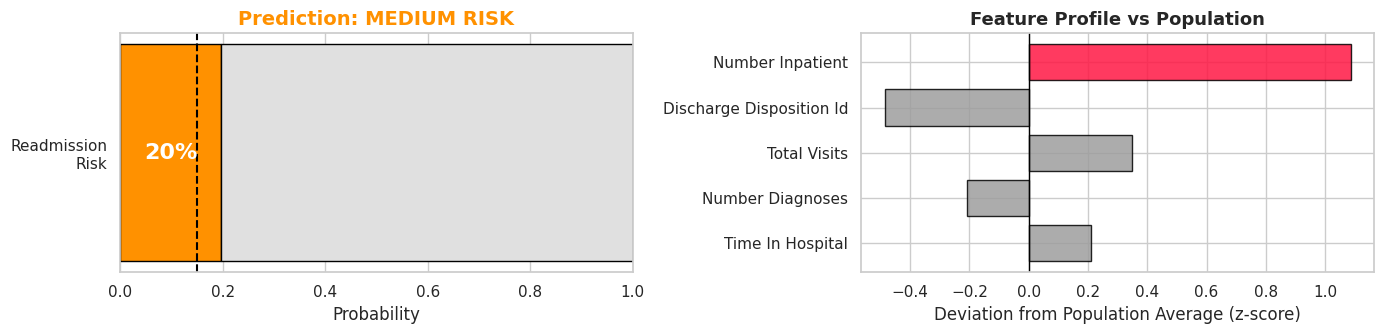

{'probability': np.float32(0.197),
 'prediction': 1,
 'risk_level': 'MEDIUM RISK'}

In [49]:
# Example from the project proposal: high-risk patient
predict_patient(
    age_group=65,               # Age group: 60-70
    number_inpatient=2,         # 2 prior inpatient visits
    num_medications=15,         # 15 medications
    time_in_hospital=5,         # 5 days in hospital
)

### Example 2 — Low-Risk Patient
A younger patient with no prior inpatient visits and a short hospital stay:

   PATIENT READMISSION RISK ASSESSMENT

   Input:
     Age group:               35
     Number of inpatient visits: 0
     Number of medications:   8
     Time in hospital:        2 days
     Number of diagnoses:     3
     Discharge disposition:   1

   Output:
     Predicted probability of readmission:  0.08
     Binary prediction:  0 (Low risk)
     Risk level:  LOW RISK

   Top contributing features:
   Feature                       Patient  Pop Avg       Status
   ----------------------------------------------------------
   number_inpatient                  0.0      0.6    BELOW AVG
   discharge_disposition_id          1.0      3.5       NORMAL
   total_visits                      0.0      1.2    BELOW AVG
   number_diagnoses                  3.0      7.4    BELOW AVG
   time_in_hospital                  2.0      4.4    BELOW AVG


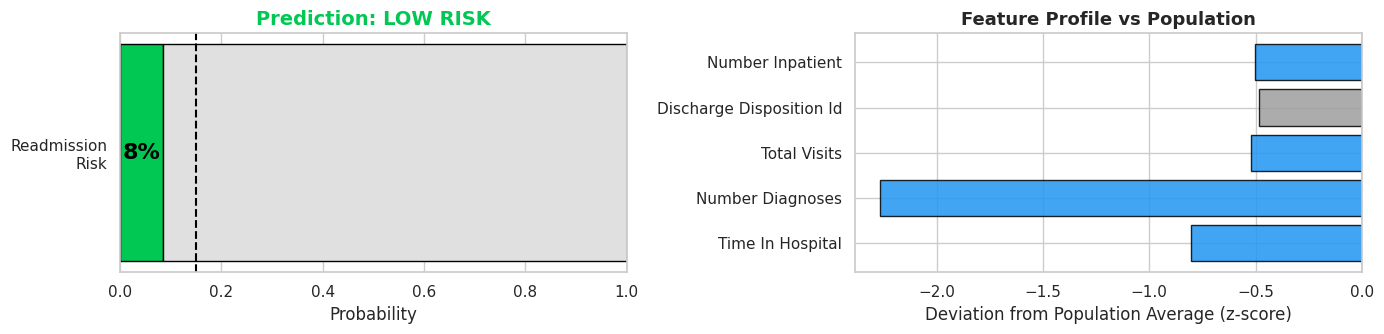

{'probability': np.float32(0.0848), 'prediction': 0, 'risk_level': 'LOW RISK'}

In [50]:
# Example 2: low-risk patient — young, first visit, short stay
predict_patient(
    age_group=35,               # Age group: 30-40
    number_inpatient=0,         # No prior inpatient visits
    num_medications=8,          # Fewer medications
    time_in_hospital=2,         # 2-day stay
    number_diagnoses=3,         # Few diagnoses
)

### Example 3 — Frequent Readmitter
An elderly patient with extensive hospital history — the kind of case where early intervention could prevent readmission:

   PATIENT READMISSION RISK ASSESSMENT

   Input:
     Age group:               75
     Number of inpatient visits: 5
     Number of medications:   22
     Time in hospital:        8 days
     Number of diagnoses:     9
     Discharge disposition:   1

   Output:
     Predicted probability of readmission:  0.50
     Binary prediction:  1 (High risk)
     Risk level:  HIGH RISK

   Top contributing features:
   Feature                       Patient  Pop Avg       Status
   ----------------------------------------------------------
   number_inpatient                  5.0      0.6    ABOVE AVG
   discharge_disposition_id          1.0      3.5       NORMAL
   total_visits                      8.0      1.2    ABOVE AVG
   number_diagnoses                  9.0      7.4    ABOVE AVG
   time_in_hospital                  8.0      4.4    ABOVE AVG


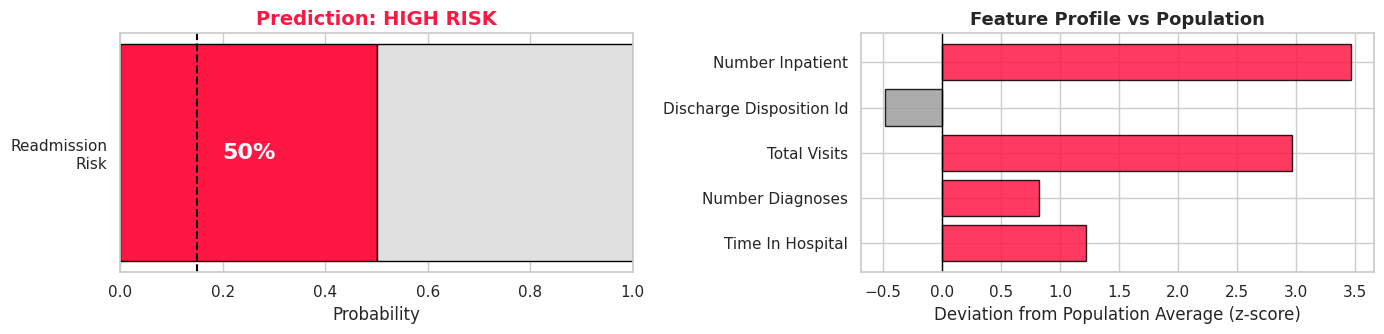

{'probability': np.float32(0.5008), 'prediction': 1, 'risk_level': 'HIGH RISK'}

In [51]:
# Example 3: frequent readmitter — elderly, many prior visits
predict_patient(
    age_group=75,               # Age group: 70-80
    number_inpatient=5,         # 5 prior inpatient visits (very high)
    num_medications=22,         # Many medications
    time_in_hospital=8,         # Long stay
    number_diagnoses=9,         # Many diagnoses
    number_emergency=3,         # 3 prior ER visits
)

---
## Export Model Artifacts for Streamlit Dashboard

Save the trained model, scaler, feature names, PFI results, and population statistics so that the Streamlit app (`streamlit_app.py`) can load them without re-training.

In [56]:
import joblib, json, os

artifact_dir = os.path.join('..', 'model_artifacts')
os.makedirs(artifact_dir, exist_ok=True)

# 1. Model & scaler
joblib.dump(best_model, os.path.join(artifact_dir, 'model.joblib'))
joblib.dump(scaler, os.path.join(artifact_dir, 'scaler.joblib'))

# 2. Feature names
with open(os.path.join(artifact_dir, 'feature_names.json'), 'w') as f:
    json.dump(feature_names, f)

# 3. PFI results
pfi_results.to_csv(os.path.join(artifact_dir, 'pfi_results.csv'), index=False)

# 4. Population statistics (mean, std, median, min, max for numeric features)
num_features = [c for c in df.select_dtypes(include='number').columns]
pop_stats = df[num_features].agg(['mean', 'std', 'median', 'min', 'max']).T
pop_stats.to_csv(os.path.join(artifact_dir, 'population_stats.csv'))

# 5. Config (threshold, model name, results)
config = {
    'optimal_threshold': float(optimal_threshold),
    'best_model_name': best_name,
    'test_roc_auc': float(results[best_name]['roc_auc']),
    'model_results': {name: {k: float(v) for k, v in res.items()}
                      for name, res in results.items()},
}
with open(os.path.join(artifact_dir, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print(f'Artifacts saved to {artifact_dir}/')
for fname in sorted(os.listdir(artifact_dir)):
    fpath = os.path.join(artifact_dir, fname)
    print(f'  {fname} ({os.path.getsize(fpath) / 1024:.1f} KB)')

Artifacts saved to ../model_artifacts/
  config.json (0.8 KB)
  feature_names.json (0.9 KB)
  model.joblib (656.3 KB)
  pfi_results.csv (0.9 KB)
  population_stats.csv (1.2 KB)
  scaler.joblib (2.8 KB)


---
## 17. Conclusion

### Summary

| Step | Description |
|------|-------------|
| **Data** | 101,766 patient encounters from 130 US hospitals |
| **Target** | Binary — readmitted within 30 days (1) vs. not (0) |
| **Class Imbalance** | Handled via SMOTE on training data only |
| **Models** | Logistic Regression, Random Forest, XGBoost |
| **Hyperparameter Tuning** | GridSearchCV (3-fold, ROC-AUC) on all three models |
| **Evaluation** | Accuracy, Precision, Recall, F1, ROC-AUC |
| **Best Model** | XGBoost — selected based on ROC-AUC + CV stability |
| **Explainability** | PFI and PDP applied on best model only |
| **Threshold** | Optimized for maximum F1 score (0.50 → 0.15) |
| **Dashboard** | Streamlit app — Explainable AI tool for clinical staff |

### Key Findings
- Class imbalance (~11% positive) required SMOTE to enable meaningful model learning.
- GridSearchCV confirmed robust hyperparameter choices — XGBoost achieved the highest ROC-AUC.
- **Top predictors**: `number_inpatient` and `discharge_disposition_id` dominate — prior hospital utilization is the strongest signal for readmission risk.
- Partial Dependence Plots confirmed a strong monotonic relationship between prior inpatient visits and readmission probability.
- Threshold optimization from 0.50 to 0.15 improved recall from 2% to 44%, critical for clinical use where missing a readmission has high cost.
- The Streamlit dashboard wraps these findings into a clinical decision support tool with What-If analysis and real-time risk scoring.